<a href="https://colab.research.google.com/github/German-rl/resistencia-bacteriana/blob/main/Resistencia_antibioticos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:

url='https://raw.githubusercontent.com/German-rl/resistencia-bacteriana/refs/heads/main/Data/raw/ACUMULATIVO%20FINAL%20MICROBIANO.csv'

df = pd.read_csv(url)

df.head(20)

,Microorganismo,ANTIMICROBIANO,R,I,S,X,Total general,Clasificacion_bacter
0,Escherichia coli,Amikacina,36.0,18.0,1501.0,NaN,1555,Negativo
1,Escherichia coli,Amoxicilina-Clavulanato,136.0,240.0,464.0,NaN,840,Negativo
2,Escherichia coli,Ampicilina,1274.0,10.0,275.0,NaN,1559,Negativo
3,Escherichia coli,Ampicilina-Sulbactam,310.0,153.0,255.0,NaN,718,Negativo
4,Escherichia coli,Cefazolina,927.0,NaN,6.0,623.0,1556,Negativo
5,Escherichia coli,Cefepima,854.0,59.0,639.0,NaN,1552,Negativo
6,Escherichia coli,Cefoxitina,292.0,87.0,1179.0,NaN,1558,Negativo
7,Escherichia coli,Ceftazidima,849.0,16.0,692.0,NaN,1557,Negativo
8,Escherichia coli,Ceftriaxona,925.0,9.0,624.0,NaN,1558,Negativo
9,Escherichia coli,Cefuroxima,513.0,15.0,312.0,NaN,840,Negativo


In [3]:
df.isna().sum()

,0
Microorganismo,0
ANTIMICROBIANO,80
R,503
I,1212
S,541
X,1313
Total general,0
Clasificacion_bacter,80


In [4]:
#Los valores NaN se igualan a 0.
df=df.fillna(0)
df = df[~df['Microorganismo'].str.contains('Total', case=False, na=False)]
df.head(50)

,Microorganismo,ANTIMICROBIANO,R,I,S,X,Total general,Clasificacion_bacter
0,Escherichia coli,Amikacina,36.0,18.0,1501.0,0.0,1555,Negativo
1,Escherichia coli,Amoxicilina-Clavulanato,136.0,240.0,464.0,0.0,840,Negativo
2,Escherichia coli,Ampicilina,1274.0,10.0,275.0,0.0,1559,Negativo
3,Escherichia coli,Ampicilina-Sulbactam,310.0,153.0,255.0,0.0,718,Negativo
4,Escherichia coli,Cefazolina,927.0,0.0,6.0,623.0,1556,Negativo
5,Escherichia coli,Cefepima,854.0,59.0,639.0,0.0,1552,Negativo
6,Escherichia coli,Cefoxitina,292.0,87.0,1179.0,0.0,1558,Negativo
7,Escherichia coli,Ceftazidima,849.0,16.0,692.0,0.0,1557,Negativo
8,Escherichia coli,Ceftriaxona,925.0,9.0,624.0,0.0,1558,Negativo
9,Escherichia coli,Cefuroxima,513.0,15.0,312.0,0.0,840,Negativo


In [5]:
#se convierten en porcentajes
df['%R']=(df['R']/df['Total general'])*100
df['%I']=(df['I']/df['Total general'])*100
df['%S']=(df['S']/df['Total general'])*100
df['%X']=(df['X']/df['Total general'])*100
df.head(10)

,Microorganismo,ANTIMICROBIANO,R,I,S,X,Total general,Clasificacion_bacter,%R,%I,%S,%X
0,Escherichia coli,Amikacina,36.0,18.0,1501.0,0.0,1555,Negativo,2.315113,1.157556,96.527331,0.00000
1,Escherichia coli,Amoxicilina-Clavulanato,136.0,240.0,464.0,0.0,840,Negativo,16.190476,28.571429,55.238095,0.00000
2,Escherichia coli,Ampicilina,1274.0,10.0,275.0,0.0,1559,Negativo,81.719051,0.641437,17.639513,0.00000
3,Escherichia coli,Ampicilina-Sulbactam,310.0,153.0,255.0,0.0,718,Negativo,43.175487,21.309192,35.515320,0.00000
4,Escherichia coli,Cefazolina,927.0,0.0,6.0,623.0,1556,Negativo,59.575835,0.000000,0.385604,40.03856
5,Escherichia coli,Cefepima,854.0,59.0,639.0,0.0,1552,Negativo,55.025773,3.801546,41.172680,0.00000
6,Escherichia coli,Cefoxitina,292.0,87.0,1179.0,0.0,1558,Negativo,18.741977,5.584082,75.673941,0.00000
7,Escherichia coli,Ceftazidima,849.0,16.0,692.0,0.0,1557,Negativo,54.527938,1.027617,44.444444,0.00000
8,Escherichia coli,Ceftriaxona,925.0,9.0,624.0,0.0,1558,Negativo,59.370988,0.577664,40.051348,0.00000
9,Escherichia coli,Cefuroxima,513.0,15.0,312.0,0.0,840,Negativo,61.071429,1.785714,37.142857,0.00000


##Resistencia por clasificación de la bacteria (Gram Positiva y Negativa)

In [6]:
#Se realiza un agrupamiento entre tipo de bacterias gram positivas y gram negativas resistentes
resistxclass_mediane=df.groupby(['Clasificacion_bacter'])['%R'].median()
resistxclass_mediane

,%R
Clasificacion_bacter,
Negativo,42.520017
Positivo,4.073615


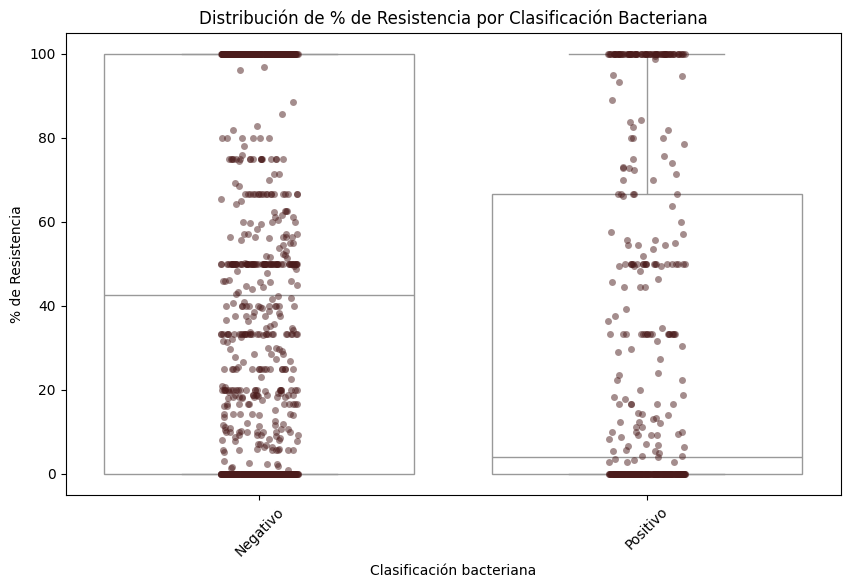

In [7]:
#boxplot del porciento de bacterias resistentes clasificadas como gram positiva y gram negativas
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x='Clasificacion_bacter',
    y='%R',
    color='#FFFFFF'

)
sns.stripplot(
    data=df,
    x='Clasificacion_bacter',
    y='%R',
    color='#4B1C1C',  # marrón oscuro
    alpha=0.5,
    jitter=True
)

plt.xticks(rotation=45)
plt.title('Distribución de % de Resistencia por Clasificación Bacteriana')
plt.xlabel('Clasificación bacteriana')
plt.ylabel('% de Resistencia')

plt.show()


| Clasificación bacteriana | Mediana del Porcentaje de resistencia |
|--------------------------|---------------------------|
| Negativo                 | 42.52                     |
| Positivo                 | 4.07                      |

En la tabla se observa una diferencia marcada en los niveles de resistencia entre las bacterias Gram negativas y Gram positivas, evidenciando que las bacterias Gram negativas presentan una mayor tendencia a exhibir porcentajes más altos de resistencia antimicrobiana.

##Bacterias con mayores porcentajesde Resistencia

In [8]:
#agrupamiento por microorganismo
totalxmo=df.groupby('Microorganismo')[['R', 'I', 'S', 'X','Total general' ]].sum()
totalxmo.sort_values(by='Total general', ascending=False).head(10)

,R,I,S,X,Total general
Microorganismo,,,,,
Escherichia coli,11482.0,1183.0,15485.0,2227.0,30377
Klebsiella pneumoniae,3226.0,370.0,4745.0,939.0,9280
Staphylococcus aureus,1230.0,103.0,3736.0,58.0,5127
Pseudomonas aeruginosa,2829.0,160.0,1000.0,172.0,4161
Staphylococcus epidermidis,1374.0,86.0,1967.0,42.0,3469
Enterobacter cloacae,1308.0,130.0,1396.0,229.0,3063
Klebsiella aerogenes,1103.0,94.0,857.0,163.0,2217
Enterococcus faecalis,622.0,45.0,761.0,92.0,1520
Klebsiella oxytoca,501.0,56.0,683.0,105.0,1345


In [9]:
#Porcentajes de Resistencia
totalxmo['%R']=(totalxmo['R']/totalxmo['Total general'])*100
totalxmo['%I']=(totalxmo['I']/totalxmo['Total general'])*100
totalxmo['%S']=(totalxmo['S']/totalxmo['Total general'])*100
totalxmo['%X']=(totalxmo['X']/totalxmo['Total general'])*100
totalxmo_sortR=totalxmo.sort_values(by='%R', ascending=False).head(10)
totalxmo_sortR

,R,I,S,X,Total general,%R,%I,%S,%X
Microorganismo,,,,,,,,,
Stenotrophomonas maltophilia,480.0,12.0,67.0,0.0,559,85.867621,2.146691,11.985689,0.000000
Burkholderia cepacia complejo,32.0,2.0,6.0,1.0,41,78.048780,4.878049,14.634146,2.439024
Hafnia alvei,14.0,2.0,2.0,0.0,18,77.777778,11.111111,11.111111,0.000000
Pseudomonas mendocina,13.0,1.0,0.0,3.0,17,76.470588,5.882353,0.000000,17.647059
Serratia liquefaciens,29.0,2.0,6.0,1.0,38,76.315789,5.263158,15.789474,2.631579
Citrobacter youngae,27.0,3.0,4.0,2.0,36,75.000000,8.333333,11.111111,5.555556
Citrobacter braakii,28.0,3.0,7.0,0.0,38,73.684211,7.894737,18.421053,0.000000
Streptococcus sobrinus,8.0,1.0,2.0,0.0,11,72.727273,9.090909,18.181818,0.000000
Pseudomonas aeruginosa,2829.0,160.0,1000.0,172.0,4161,67.988464,3.845230,24.032684,4.133622


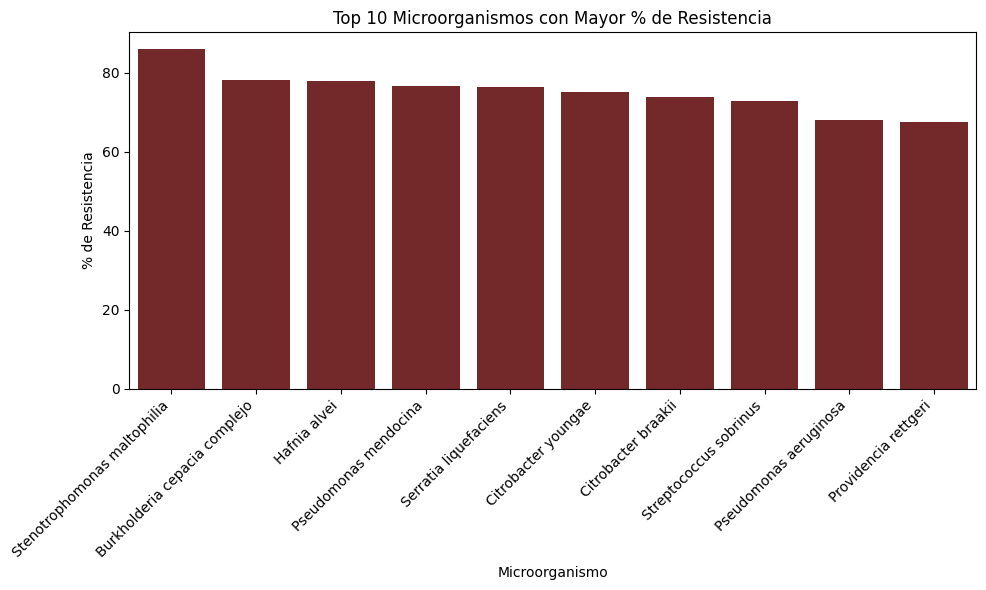

In [10]:
#gráfico de los diez microorganismos con mayor porcentaje de resistencia
plt.figure(figsize=(10,6))
sns.barplot(
    data=totalxmo_sortR,
    x='Microorganismo',
    y='%R',
    color='#7F1D1D'
)

plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Microorganismos con Mayor % de Resistencia')
plt.xlabel('Microorganismo')
plt.ylabel('% de Resistencia')

plt.tight_layout()
plt.show()


Ver artículo https://www.elsevier.es/es-revista-enfermedades-infecciosas-microbiologia-clinica-28-articulo-stenotrophomonas-maltophilia-un-patogeno-nosocomial-13083366

Esta gráfica muestra el top 10 de las bacterias con mayor tendencia a presentar porcentajes elevados de resistencia antimicrobiana. No obstante, este resultado no refleja la recurrencia absoluta de bacterias resistentes, por lo que es necesario complementar el análisis con el gráfico subsecuente, donde se presenta la frecuencia de aparición de dichas bacterias resistentes.

##Microorganismo más susceptible

In [11]:
#selecciónde los 10 microorganismos con mayor suseptibilidad a antibióticos
totalxmo_sortS=totalxmo.sort_values(by='%S', ascending=False).head(10)
totalxmo_sortS

,R,I,S,X,Total general,%R,%I,%S,%X
Microorganismo,,,,,,,,,
Streptococcus grupo A (Strep. pyogenes),0.0,0.0,12.0,0.0,12,0.000000,0.000000,100.000000,0.000000
Staphylococcus auricularis,1.0,0.0,14.0,0.0,15,6.666667,0.000000,93.333333,0.000000
Staphylococcus pasteuri,2.0,0.0,28.0,0.0,30,6.666667,0.000000,93.333333,0.000000
Acinetobacter lwoffii/haemolyticus,0.0,0.0,12.0,1.0,13,0.000000,0.000000,92.307692,7.692308
Streptococcus dysgalactiae ssp equisimilis,1.0,0.0,11.0,0.0,12,8.333333,0.000000,91.666667,0.000000
Staphylococcus xylosus,2.0,0.0,14.0,0.0,16,12.500000,0.000000,87.500000,0.000000
Staphylococcus caprae,0.0,0.0,13.0,2.0,15,0.000000,0.000000,86.666667,13.333333
Streptococcus pyogenes (Strep. grupo A),3.0,1.0,20.0,0.0,24,12.500000,4.166667,83.333333,0.000000
Streptococcus agalactiae (Strep. grupo B),8.0,0.0,49.0,6.0,63,12.698413,0.000000,77.777778,9.523810


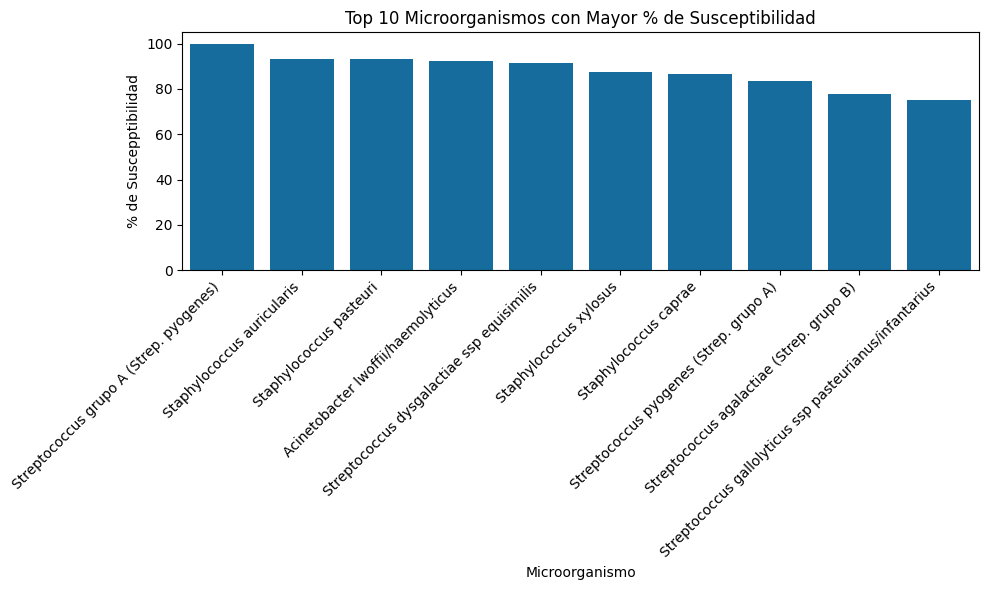

In [12]:
#gráfico de los 10 microorganismos más suseptibles
plt.figure(figsize=(10,6))
sns.barplot(
    data=totalxmo_sortS,
    x='Microorganismo',
    y='%S',
    color='#0072B2'
)

plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Microorganismos con Mayor % de Susceptibilidad')
plt.xlabel('Microorganismo')
plt.ylabel('% de Suscepptibilidad')

plt.tight_layout()
plt.show()

Esta gráfica muestra el top 10 de las bacterias con mayor tendencia a ser susceptibles a los antimicrobianos.

##Resistencia por antibiótico

In [13]:
#Agrupamiento por antibiótico
totalxant=df.groupby('ANTIMICROBIANO')[['R', 'I', 'S', 'X','Total general' ]].sum()
totalxant['%R']=(totalxant['R']/totalxant['Total general'])*100
totalxant['%I']=(totalxant['I']/totalxant['Total general'])*100
totalxant['%S']=(totalxant['S']/totalxant['Total general'])*100
totalxant['%X']=(totalxant['X']/totalxant['Total general'])*100
totalxant_sort=totalxant.sort_values(by='%R', ascending=False).head(10)
totalxant_sort

,R,I,S,X,Total general,%R,%I,%S,%X
ANTIMICROBIANO,,,,,,,,,
Ampicilina,2676.0,14.0,409.0,0.0,3099,86.350436,0.451759,13.197806,0.000000
Penicilina G,478.0,2.0,77.0,25.0,582,82.130584,0.343643,13.230241,4.295533
Tetraciclina,879.0,4.0,385.0,0.0,1268,69.321767,0.315457,30.362776,0.000000
Cefazolina,1966.0,2.0,31.0,927.0,2926,67.190704,0.068353,1.059467,31.681476
Cefuroxima,796.0,22.0,438.0,0.0,1256,63.375796,1.751592,34.872611,0.000000
Oxacilina,387.0,0.0,244.0,0.0,631,61.331220,0.000000,38.668780,0.000000
Ceftriaxona,1735.0,12.0,1151.0,24.0,2922,59.377139,0.410678,39.390828,0.821355
Trimetoprim-Sulfametoxazol,2130.0,0.0,1516.0,0.0,3646,58.420187,0.000000,41.579813,0.000000
Ampicilina-Sulbactam,945.0,220.0,499.0,0.0,1664,56.790865,13.221154,29.987981,0.000000


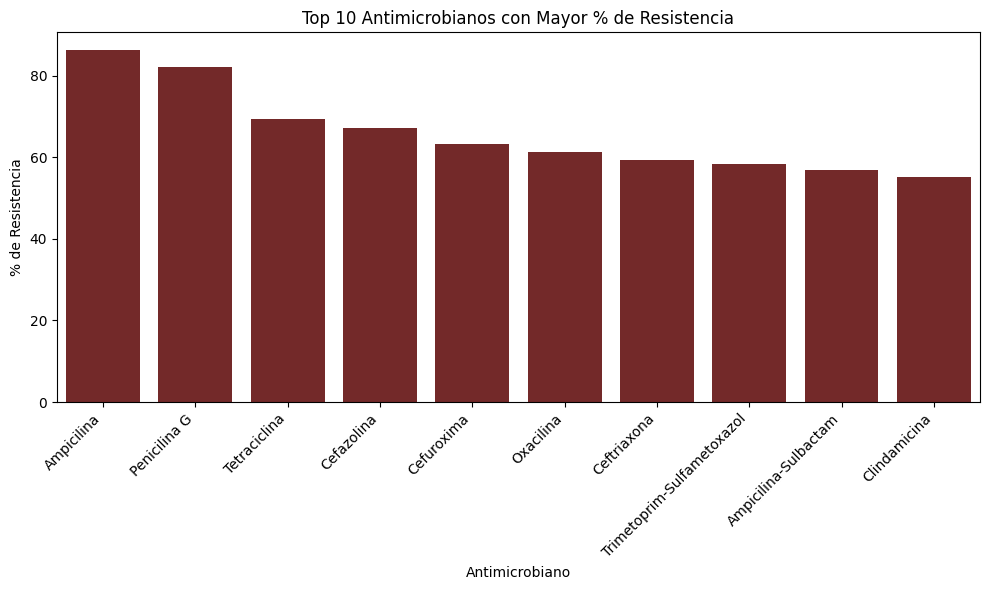

In [14]:
#Gráfico de los diez antibioticos con mayor porcentaje de bacetrias resistentes
plt.figure(figsize=(10,6))
sns.barplot(
    data=totalxant_sort,
    x='ANTIMICROBIANO',
    y='%R',
    color='#7F1D1D'
)

plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Antimicrobianos con Mayor % de Resistencia')
plt.xlabel('Antimicrobiano')
plt.ylabel('% de Resistencia')

plt.tight_layout()
plt.show()

Esta gráfica presenta el top 10 de los antibacterianos frente a los cuales se observa el mayor nivel de resistencia bacteriana.

##Microorganismos más comunes

In [15]:
#Agrupamiento por microorganismos
totalxmo.sort_valuesT=totalxmo.sort_values(by='Total general', ascending=False).head(10)
top10=totalxmo.sort_valuesT
top10=top10.reset_index()

/tmp/ipython-input-1873447700.py:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  totalxmo.sort_valuesT=totalxmo.sort_values(by='Total general', ascending=False).head(10)


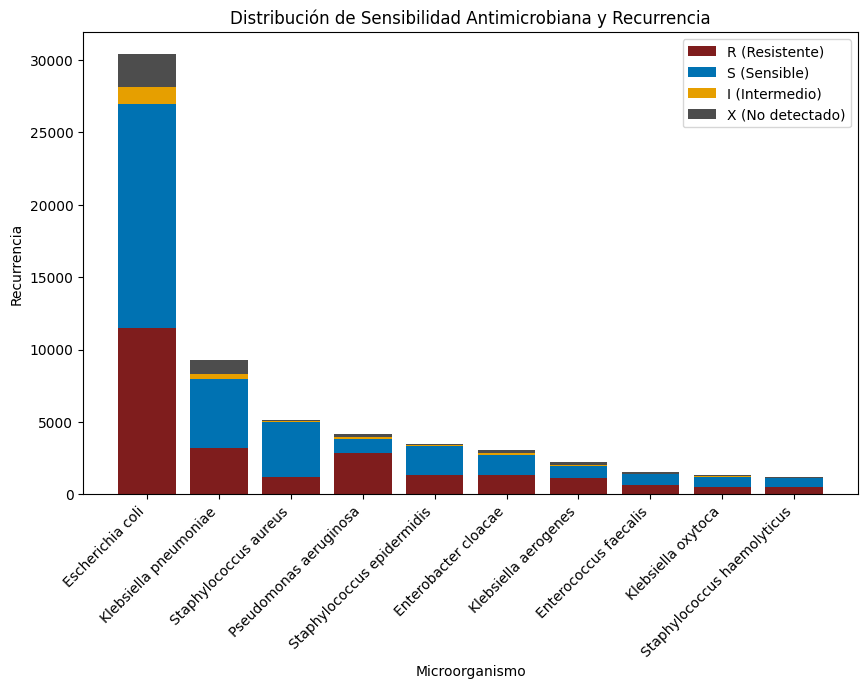

In [16]:
#Gráfico de los microorganismos más recurrentes y su conteo de resistencia

plt.figure(figsize=(10,6))

plt.bar(top10['Microorganismo'], top10['R'],
        label='R (Resistente)', color='#7F1D1D')

plt.bar(top10['Microorganismo'], top10['S'],
        bottom=top10['R'],
        label='S (Sensible)', color='#0072B2')

plt.bar(top10['Microorganismo'], top10['I'],
        bottom=top10['R'] + top10['S'],
        label='I (Intermedio)', color='#E69F00')

plt.bar(top10['Microorganismo'], top10['X'],
        bottom=top10['R'] + top10['S'] + top10['I'],
        label='X (No detectado)', color='#4D4D4D')

plt.xticks(rotation=45, ha='right')
plt.ylabel('Recurrencia')
plt.xlabel('Microorganismo')
plt.title('Distribución de Sensibilidad Antimicrobiana y Recurrencia')
plt.legend()

Este gráfico muestra los microorganismos más recurrentes en los cultivos bacterianos, desglosando la cantidad de aislamientos clasificados como resistentes, susceptibles, de susceptibilidad intermedia y no clasificados

##Proporción de Microorganismos Resistentes
P(Microorganismo|Resistente)

In [17]:
total_R = totalxmo['R'].sum()

totalxmo['Proporcion_R'] = totalxmo['R'] / total_R
totalxmo
top10PR = totalxmo.sort_values('Proporcion_R', ascending=False).head(10)

top10PR=top10PR.reset_index()
top10PR

,Microorganismo,R,I,S,X,Total general,%R,%I,%S,%X,Proporcion_R
0,Escherichia coli,11482.0,1183.0,15485.0,2227.0,30377,37.798334,3.894394,50.976067,7.331205,0.425511
1,Klebsiella pneumoniae,3226.0,370.0,4745.0,939.0,9280,34.762931,3.987069,51.131466,10.118534,0.119552
2,Pseudomonas aeruginosa,2829.0,160.0,1000.0,172.0,4161,67.988464,3.845230,24.032684,4.133622,0.104840
3,Staphylococcus epidermidis,1374.0,86.0,1967.0,42.0,3469,39.607956,2.479101,56.702220,1.210724,0.050919
4,Enterobacter cloacae,1308.0,130.0,1396.0,229.0,3063,42.703232,4.244205,45.576232,7.476330,0.048473
5,Staphylococcus aureus,1230.0,103.0,3736.0,58.0,5127,23.990638,2.008972,72.869124,1.131266,0.045583
6,Klebsiella aerogenes,1103.0,94.0,857.0,163.0,2217,49.751917,4.239964,38.655841,7.352278,0.040876
7,Enterococcus faecalis,622.0,45.0,761.0,92.0,1520,40.921053,2.960526,50.065789,6.052632,0.023051
8,Staphylococcus haemolyticus,522.0,23.0,615.0,18.0,1178,44.312394,1.952462,52.207131,1.528014,0.019345
9,Klebsiella oxytoca,501.0,56.0,683.0,105.0,1345,37.249071,4.163569,50.780669,7.806691,0.018567


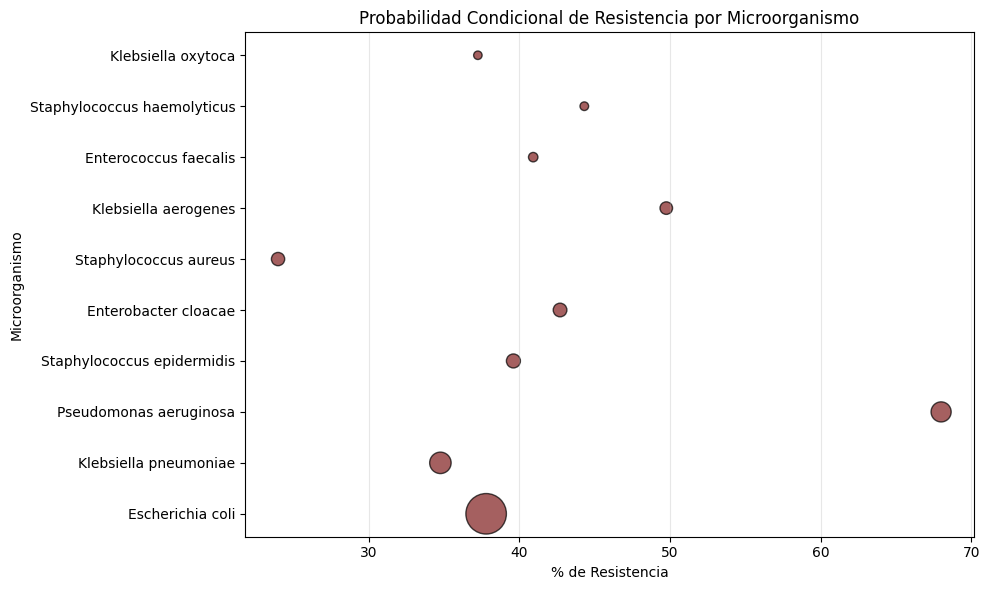

In [18]:
#Gráfico de probabilidad (microorganismo|Resitencia)

plt.figure(figsize=(10,6))

plt.scatter(
    x=top10PR['%R'],
    y=top10PR['Microorganismo'],
    s=top10PR['Proporcion_R'] * 2000,   # escala visual
    alpha=0.7,
    color='#7F1D1D',
    edgecolor='black'
)

plt.xlabel('% de Resistencia')
plt.ylabel('Microorganismo')
plt.title('Probabilidad Condicional de Resistencia por Microorganismo')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Probabilidad condicional: se refiere a la probabilidad de que un microorganismo específico esté presente cuando ya se sabe que existe resistencia bacteriana.

Para el análisis, se seleccionan los 10 microorganismos con mayor probabilidad condicional; es decir, dado que se ha identificado una bacteria resistente, se determinan cuáles son los diez microorganismos que con mayor frecuencia están asociados a dicha resistencia.

$P(\text{Microorganismo}_i \mid R) = \frac{\text{Resistentes del microorganismo } i}{\text{Total de microorganismos resistentes}}$


##Perfil de Resistencia antrimicrobiana

In [19]:
#función para la generación de gráficos de perfil de resistencia
def graf_ant(df, Microorganismo):
  ''' Función para la generación de gráficos de barras de perfiles de resistencia
      df:base de datos
      Microorganismo: Entrada de la columna Microorganismo en df
      '''

  df=df[df['Microorganismo']== Microorganismo]
  plt.figure(figsize=(10,8))

  plt.barh(df['ANTIMICROBIANO'], df['%R'],
             label='R (Resistente)', color='#7F1D1D')

  plt.barh(df['ANTIMICROBIANO'], df['%S'],
             left=df['%R'],
             label='S (Sensible)', color='#0072B2')

  plt.barh(df['ANTIMICROBIANO'], df['%I'],
             left=df['%R'] + df['%S'],
             label='I (Intermedio)', color='#E69F00')

  plt.barh(df['ANTIMICROBIANO'], df['%X'],
             left=df['%R'] + df['%S'] + df['%I'],
             label='X (No detectado)', color='#4D4D4D')

  plt.xlabel('Porcentaje')
  plt.ylabel('Antibiótico')
  plt.title(f'Perfil de resistencia Antimicrobiana de {Microorganismo}')

  plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

  plt.tight_layout()
  plt.show()

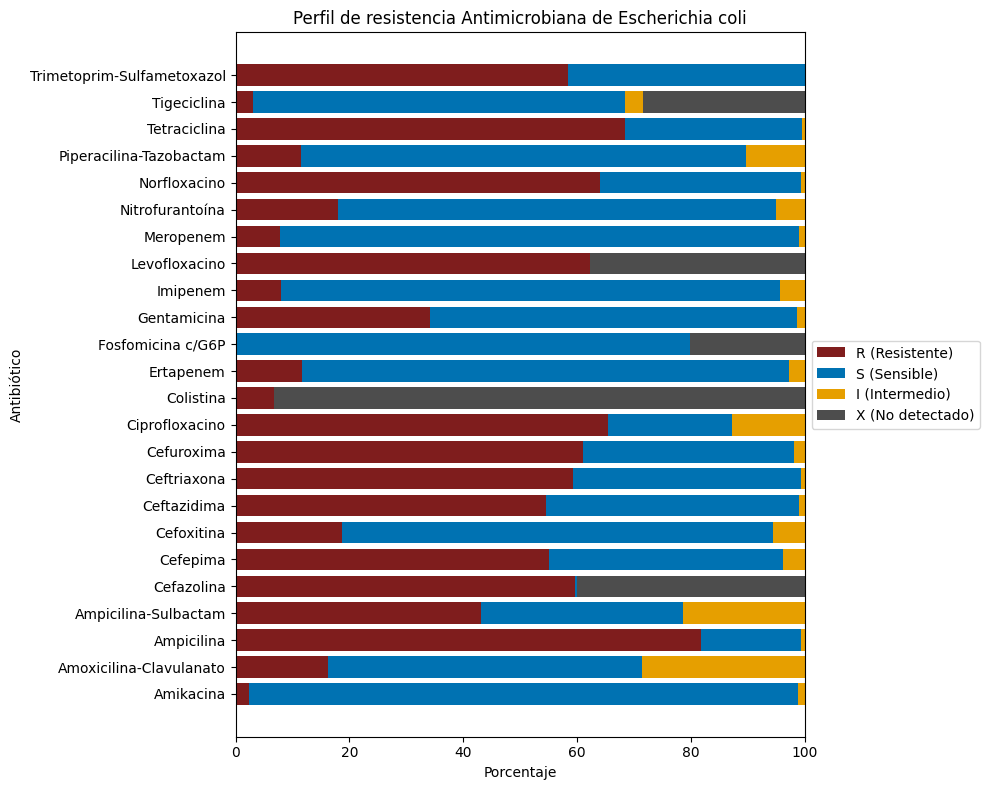

In [20]:
perfil_Escherichia= graf_ant(df, 'Escherichia coli')

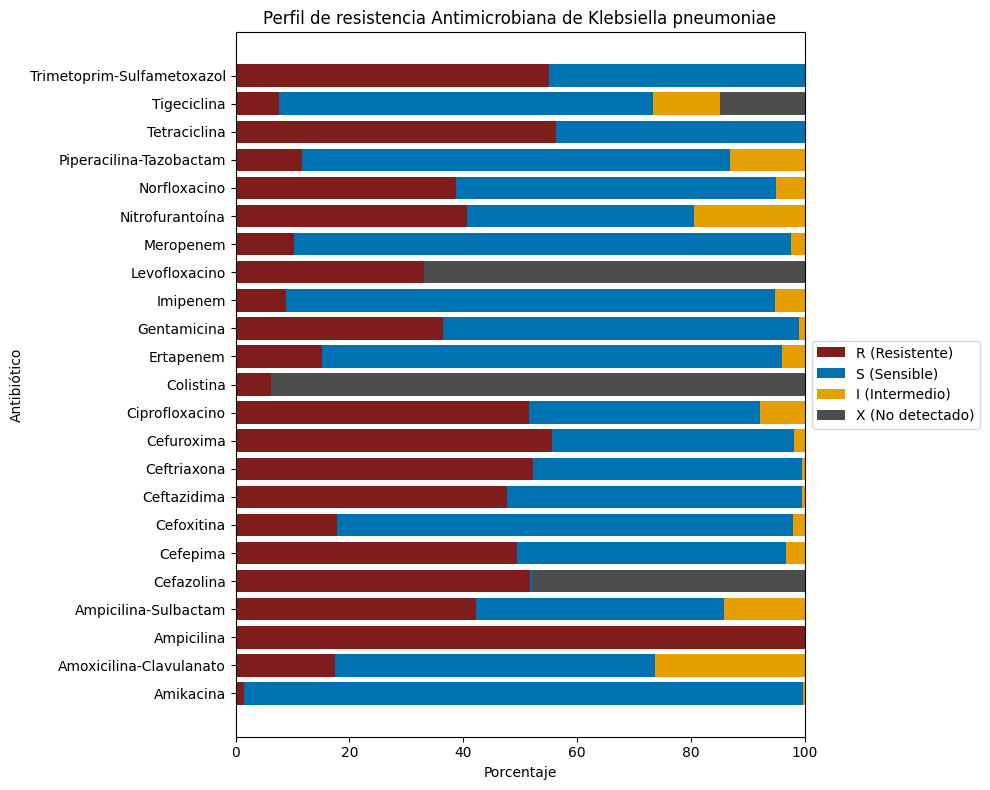

In [21]:
perfil_Klebsiella=graf_ant(df, 'Klebsiella pneumoniae')

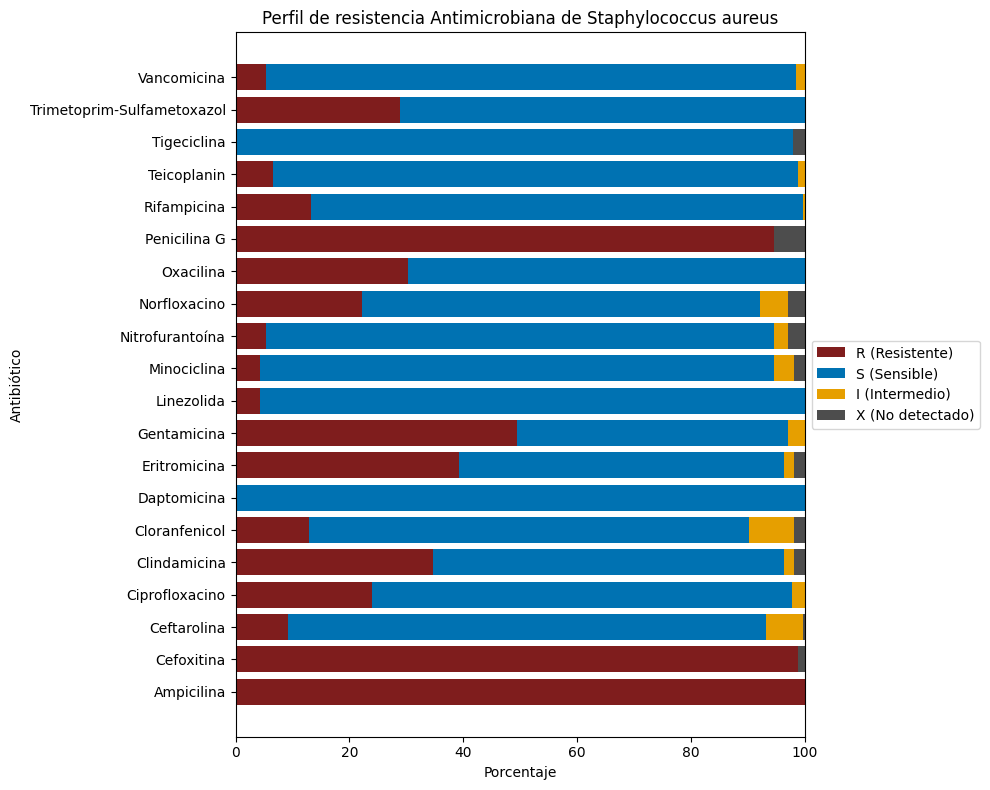

In [22]:
perfil_staphylococcus=graf_ant(df,'Staphylococcus aureus')